O caso abaixo achará o comportamento ótimo da bateria para qualquer cenário


✓ Objetivo total: 8759.8722 BRL/dia

 base (π=0.6)
 Hora  Rede_compra  Rede_venda   PV  Demanda  BESS_carga  BESS_descarga  E_BESS  state
    0          0.0        0.00 0.00     1.93        0.00            0.0    0.00      1
    1          0.0       -0.00 0.00     1.61        0.00            0.0   -0.00      0
    2          0.0       -0.00 0.00     1.41       -0.00            0.0    0.00      0
    3          0.0       -0.00 0.00     1.33       -0.00            0.0    0.00      0
    4          0.0        0.04 0.08     1.38        0.04            0.0    0.04      1
    5          0.0        0.23 0.46     1.64        0.23            0.0    0.24      1
    6          0.0        0.54 1.07     1.94        0.54            0.0    0.71      1
    7          0.0        0.79 1.58     1.74        0.79            0.0    1.41      1
    8          0.0        1.22 2.43     1.83        1.22            0.0    2.48      0
    9          0.0        1.37 2.75     1.84        1.37            0.0    3.6

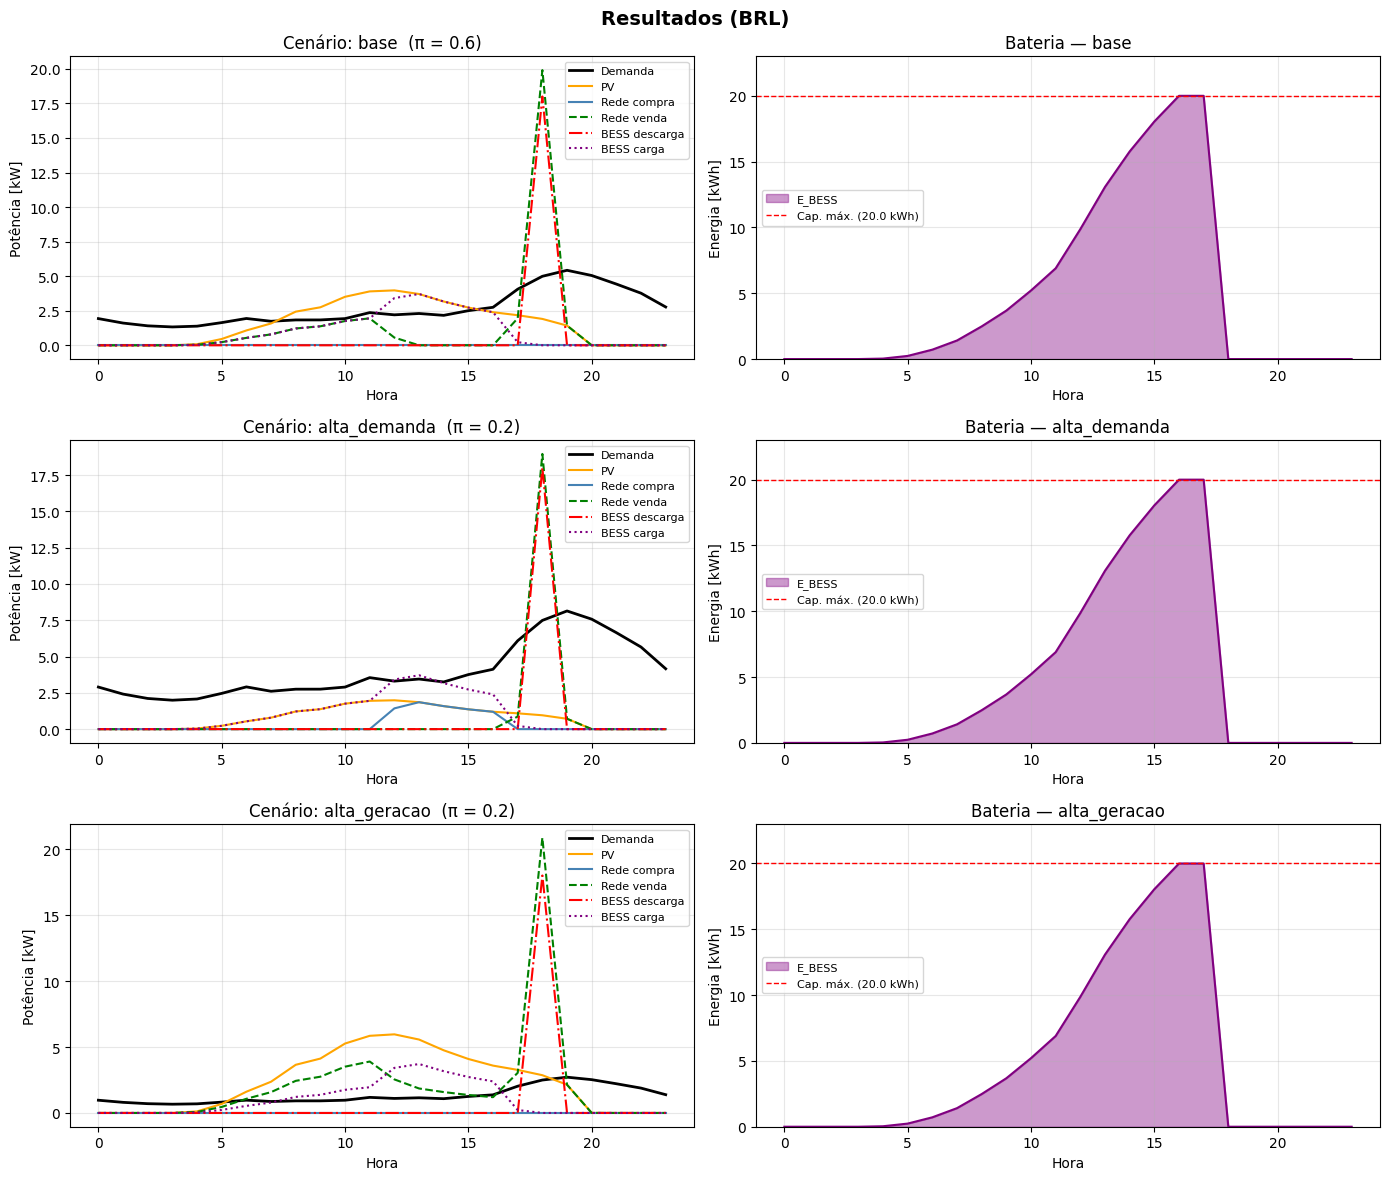


Varredura BESS (PV fixo na capacidade ótima) — valores em BRL/dia
Empty DataFrame
Columns: []
Index: []


KeyError: 'BESS_kWh'

<Figure size 800x400 with 0 Axes>

In [51]:
from pyomo.opt import SolverFactory, SolverStatus, TerminationCondition
import pyomo.environ as pyo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Dados ──────────────────────────────────────────────────────────────────────
P_demand_data = [
    1.9317, 1.6090, 1.4079, 1.3281, 1.3834, 1.6413,
    1.9395, 1.7383, 1.8341, 1.8354, 1.9312, 2.3645,
    2.2038, 2.2997, 2.1659, 2.5046, 2.7490, 4.0597,
    4.9924, 5.4257, 5.0491, 4.4294, 3.7692, 2.7716
]
P_pv_data = [
    0.0000, 0.0000, 0.0000, 0.0000, 0.0796, 0.4565,
    1.0742, 1.5790, 2.4343, 2.7488, 3.5092, 3.8988,
    3.9734, 3.7105, 3.1671, 2.7282, 2.3926, 2.1764,
    1.9083, 1.4257, 0.0034, 0.0000, 0.0000, 0.0000
]

tariff_buy = [
    0.22419, 0.22419, 0.22419, 0.22419, 0.22419, 0.22419,
    0.22419, 0.22419, 0.22419, 0.22419, 0.22419, 0.22419,
    0.22419, 0.22419, 0.22419, 0.22419, 0.22419, 0.32629,
    0.51792, 0.51792, 0.51792, 0.32629, 0.22419, 0.22419
]
parameters = {
    "Grid": {"Pmax": 90},
    "BESS": {
        "eff": 0.90,
        "self_discharge": 0.01,
        "initial capacity": 0,
    }
}
scenarios = {
    "base": {
        "P_demand": P_demand_data,
        "P_pv":     P_pv_data,
        "prob":     0.60,
    },
    "alta_demanda": {
        "P_demand": [round(x * 1.5, 4) for x in P_demand_data],
        "P_pv":     [round(x * 0.5, 4) for x in P_pv_data],
        "prob":     0.20,
    },
    "alta_geracao": {
        "P_demand": [round(x * 0.5, 4) for x in P_demand_data],
        "P_pv":     [round(x * 1.5, 4) for x in P_pv_data],
        "prob":     0.20,
    },
}


class SmartHomeStochastic:
    def __init__(self, parameters, scenarios, tariff_buy):
        self.parameters = parameters
        self.scenarios  = scenarios
        self.tariff_buy = tariff_buy
        self.results    = {}        # será preenchido em solve()

    def build(self):
        m     = pyo.ConcreteModel('SmartHome_Stochastic') # m stands for model
        self.delta = delta = 1.0

        # Conjuntos
        m.T = pyo.RangeSet(0, len(self.tariff_buy) - 1)
        m.S = pyo.Set(initialize=self.scenarios.keys())

        # Matrizes
        m.P_demand = pyo.Param(m.S, m.T,
                               initialize=lambda m, s, t: self.scenarios[s]['P_demand'][t])
        m.P_pv     = pyo.Param(m.S, m.T,
                               initialize=lambda m, s, t: self.scenarios[s]['P_pv'][t])
        m.prob     = pyo.Param(m.S,
                               initialize=lambda m, s: self.scenarios[s]['prob'])
        m.tariff   = pyo.Param(m.T,
                               initialize=lambda m, t: self.tariff_buy[t])

        # Componentes
        eff       = self.parameters['BESS']['eff']
        beta      = self.parameters['BESS']['self_discharge']
        init_cap  = self.parameters['BESS']['initial capacity']
        Pmax_grid = self.parameters['Grid']['Pmax']
        Pmax_PV   = 20.0  # kW, limite prático para telhado residencial

        
        ### VARIÁVEIS ─────────────────────────────────────────────────────────────────────

        # Variáveis decisão de capacidade (1ª etapa)
        m.BESS_capacity = pyo.Var(within=pyo.NonNegativeReals, bounds=(0, 20))
        m.BESS_Pmax     = pyo.Var(within=pyo.NonNegativeReals, bounds=(0, 1e6))

        # Binárias para operação (1ª etapa, mesma para todos os cenários)
        m.state = pyo.Var(m.T, within=pyo.Binary)

        # Variáveis operacionais (2ª etapa)
        m.Pgrid_buy       = pyo.Var(m.S, m.T, within=pyo.NonNegativeReals, bounds=(0, Pmax_grid))
        m.Pgrid_sell      = pyo.Var(m.S, m.T, within=pyo.NonNegativeReals, bounds=(0, Pmax_grid))
        m.Pgrid           = pyo.Var(m.S, m.T, within=pyo.Reals,            bounds=(-Pmax_grid, Pmax_grid))

        m.Pbess_charge    = pyo.Var(m.T, within=pyo.NonNegativeReals, bounds=(0, 1e6))
        m.Pbess_discharge = pyo.Var(m.T, within=pyo.NonNegativeReals, bounds=(0, 1e6))
        m.E_bess          = pyo.Var(m.T, within=pyo.NonNegativeReals, bounds=(0, 20))

        ### RESTRIÇÕES ──────────────────────────────────────────────────────────────────────

        def energy_capacity_limit(m, t):
            return m.E_bess[t] <= m.BESS_capacity
        m.energy_cap = pyo.Constraint(m.T, rule=energy_capacity_limit)

        def charge_limit_rule(m,t):
            return m.Pbess_charge[t] <= m.BESS_Pmax
        m.charge_limit = pyo.Constraint(m.T, rule=charge_limit_rule)

        def discharge_limit_rule(m,t):
            return m.Pbess_discharge[t] <= m.BESS_Pmax
        m.discharge_limit = pyo.Constraint(m.T, rule=discharge_limit_rule)

        # 2. Evita carga e descarga simultâneas usando as variáveis binárias
        def no_simultaneous_charge(m, t):
            return m.Pbess_charge[t] <= m.state[t] * 1e6
        m.no_simul_charge = pyo.Constraint(m.T, rule=no_simultaneous_charge)

        def no_simultaneous_discharge(m, t):
            return m.Pbess_discharge[t] <= (1 - m.state[t]) * 1e6
        m.no_simul_discharge = pyo.Constraint(m.T, rule=no_simultaneous_discharge)

        def power_balance_rule(m, s, t):
            return (+ m.Pgrid_buy[s, t]
                    + m.P_pv[s, t]
                    + m.Pbess_discharge[t]
                    ==
                    + m.Pgrid_sell[s, t]
                    + m.Pbess_charge[t])
        m.power_balance = pyo.Constraint(m.S, m.T, rule=power_balance_rule)

        def grid_balance_rule(m, s, t):
            return m.Pgrid[s, t] == m.Pgrid_buy[s, t] - m.Pgrid_sell[s, t]
        m.grid_balance = pyo.Constraint(m.S, m.T, rule=grid_balance_rule)

        def bess_energy_rule(m, t):
            charge    = eff * delta * m.Pbess_charge[t]
            discharge = delta * m.Pbess_discharge[t] / eff
            loss      = beta * delta * m.E_bess[t]

            if t == 0:
                E_prev = init_cap
            else:
                E_prev = m.E_bess[t-1]
            return m.E_bess[t] == E_prev + charge - discharge - loss
        m.bess_energy = pyo.Constraint(m.T, rule=bess_energy_rule)

        # Objetivo -------------------------------------------------------------
        
        self.CAPEX_PV          = 600.0 * 4.96              # BRL/kW
        self.OPEX_PV           = 0.02 * self.CAPEX_PV      # % do CAPEX   
        self.CAPEX_BESS        = 1156.0 * 4.96             # BRL/kWh
        self.OPEX_BESS         = self.delta * sum(m.prob[s] * sum(m.tariff[t] * m.Pgrid_buy[s, t] - 0.7 * m.tariff[t] * m.Pgrid_sell[s, t]for t in m.T)for s in m.S)
        
        def objective_rule(m):
            return (self.CAPEX_PV + self.OPEX_PV + self.CAPEX_BESS + self.OPEX_BESS)
        self.objective = m.objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

        self.model = m

    def solve(self):
        solver   = SolverFactory('highs')
        solution = solver.solve(self.model)

        m = self.model

        if (solution.solver.status == SolverStatus.ok and solution.solver.termination_condition == TerminationCondition.optimal):
            print(f"\n✓ Objetivo total: {pyo.value(m.objective):.4f} BRL/dia")
        else:
            print("✗ Solver não encontrou solução ótima.")
            print(f"  Status: {solution.solver.status}")
            print(f"  Termination: {solution.solver.termination_condition}")
            return

        # Coleta resultados em self.results para o plot usar depois
        for s in m.S:
            rows = []
            for t in m.T:
                rows.append({
                    'Hora':            t,
                    'Rede_compra':     pyo.value(m.Pgrid_buy[s, t]),
                    'Rede_venda':      pyo.value(m.Pgrid_sell[s, t]),
                    'PV':              pyo.value(m.P_pv[s, t]),
                    'Demanda':         pyo.value(m.P_demand[s, t]),
                    'BESS_carga':      pyo.value(m.Pbess_charge[t]),
                    'BESS_descarga':   pyo.value(m.Pbess_discharge[t]),
                    'E_BESS':          pyo.value(m.E_bess[t]),
                    'state':           int(pyo.value(m.state[t])),
                })

            df = pd.DataFrame(rows)
            print(f"\n {s} (π={self.scenarios[s]['prob']})")
            print(df.round(2).to_string(index=False))
            self.results[s] = df

    def plot(self):
        horas     = list(self.model.T)
        cenarios  = list(self.results.keys())
        n         = len(cenarios)

        fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(14, 4 * n), sharey=False)
        fig.suptitle("Resultados (BRL)", fontsize=14, fontweight='bold')

        for i, s in enumerate(cenarios):
            df  = self.results[s]
            ax1 = axes[i, 0]
            ax2 = axes[i, 1]

            prob = self.scenarios[s]['prob']

            ax1.plot(horas, df['Demanda'],       label='Demanda',      color='black',  linewidth=2)
            ax1.plot(horas, df['PV'],            label='PV',           color='orange', linewidth=1.5)
            ax1.plot(horas, df['Rede_compra'],   label='Rede compra',  color='steelblue', linewidth=1.5)
            ax1.plot(horas, df['Rede_venda'],    label='Rede venda',   color='green',  linewidth=1.5, linestyle='--')
            ax1.plot(horas, df['BESS_descarga'], label='BESS descarga',color='red',    linewidth=1.5, linestyle='-.')
            ax1.plot(horas, df['BESS_carga'],    label='BESS carga',   color='purple', linewidth=1.5, linestyle=':')

            ax1.set_title(f"Cenário: {s}  (π = {prob})")
            ax1.set_ylabel("Potência [kW]")
            ax1.set_xlabel("Hora")
            ax1.legend(fontsize=8)
            ax1.grid(True, alpha=0.3)

            ax2.fill_between(horas, df['E_BESS'], alpha=0.4, color='purple', label='E_BESS')
            ax2.plot(horas, df['E_BESS'], color='purple', linewidth=1.5)

            try:
                cap_max = pyo.value(self.model.BESS_capacity)
            except Exception:
                cap_max = self.parameters['BESS']['capacity']
            ax2.axhline(cap_max, color='red', linestyle='--', linewidth=1, label=f'Cap. máx. ({cap_max} kWh)')

            ax2.set_title(f"Bateria — {s}")
            ax2.set_ylabel("Energia [kWh]")
            ax2.set_xlabel("Hora")
            ax2.set_ylim(0, cap_max * 1.15)
            ax2.legend(fontsize=8)
            ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


# ── Execução ───────────────────────────────────────────────────────────────────
sh = SmartHomeStochastic(parameters, scenarios, tariff_buy)
sh.build()
sh.solve()
sh.plot()

# ── Diagnóstico: varredura de BESS fixas (mantendo PV na capacidade ótima) -- BRL
bess_list = [0, 1, 2, 4, 8, 12, 16, 20]
rows = []

df_sweep = pd.DataFrame(rows)
print('\nVarredura BESS (PV fixo na capacidade ótima) — valores em BRL/dia')
print(df_sweep)

# plota
plt.figure(figsize=(8,4))
plt.plot(df_sweep['BESS_kWh'], df_sweep['Operational_daily_BRL'], marker='o', label='Operacional (BRL/dia)')
plt.plot(df_sweep['BESS_kWh'], df_sweep['Daily_capacity_cost_BRL'], marker='o', label='Custo diário capacidade (BRL/dia)')
plt.plot(df_sweep['BESS_kWh'], df_sweep['Total_daily_BRL'], marker='o', label='Total (BRL/dia)')
plt.xlabel('BESS capacity [kWh]')
plt.grid(True)
plt.legend()
plt.title('Diagnóstico: varredura BESS (PV fixo) — BRL/dia')
plt.show()
